# Explicite Finate Difference

In [3]:
from enum import Enum
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors
import copy

In [4]:
class OptionBasicType(Enum):
	CALL = "CALL"
	PUT = "PUT"
	
class OptionExerciseType(Enum):
	EUROPEAN = "EUROPEAN"
	AMERICAN = "AMERICAN"

In [5]:
class EFD():
    def __init__(
        self,
        sigma_min: float,
        sigma_max: float,
        option_basic_type: OptionBasicType,
        option_exercise_type: OptionExerciseType,
        expiry_date: datetime,
        T0: datetime,
        strike_price: float,
        barrier_price: float = None,
        r: float = 0.0,

        delta_t: float = 0.01, # in year
        delta_s: float = 0.01,

        dividend_yield: float = 0.0,
        dividend_date: datetime = None,

        verbose: bool = True,

    ) -> None:
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max
        self.option_basic_type = option_basic_type
        self.option_exercise_type = option_exercise_type
        self.expiry_date = expiry_date
        self.T0 = T0
        self.strike_price = strike_price
        self.barrier_price = barrier_price
        self.r = r

        self.delta_t = delta_t
        self.delta_s = delta_s

        self.dividend_yield = dividend_yield
        self.dividend_date = dividend_date

        self.verbose = verbose
        
        self.initialize_grid()

    def payoff(self, S):
        if self.option_basic_type == OptionBasicType.CALL:
            return np.maximum(S - self.strike_price, 0)
        elif self.option_basic_type == OptionBasicType.PUT:
            return np.maximum(self.strike_price - S, 0)
        else:
            raise ValueError("Invalid option basic type")


    # S(underlying price) = i * delta_s is in comlumn. When i=0 then the price is 0, when i=N then the price is N*delta_s.
    # t(time) = j * delta_t is in row. When j=0 then the time is expiry date, when j=M then the time is T0.
    def initialize_grid(self):
        if self.barrier_price is None:
            self.N = int(3 * self.strike_price / self.delta_s)
        else:
            self.N = int(self.barrier_price / self.delta_s)
        self.M = int((self.expiry_date - self.T0).days / 365 / self.delta_t)
        self.grid = np.zeros((self.N + 1, self.M + 1))

        # We will also create grids for Greeks, so we can analyze them later.
        self.delta_grid = np.zeros_like(self.grid)
        self.theta_grid = np.zeros_like(self.grid)
        self.gamma_grid = np.zeros_like(self.grid)


        if self.verbose:
            print(f"Initialized grid with shape: {self.grid.shape}")

        # Right boudary condition for expired option, when time is 0, the option value is the payoff.
        self.grid[:, 0] = self.payoff(np.arange(self.N + 1) * self.delta_s)

        # Left boundary condition for underlying price is 0, the option value is 0.
        self.grid[0, :] = 0.0

        if self.barrier_price is None:
            raise NotImplementedError("Option with no barrier is not implemented yet")
        else:
            # Upper boundary condition for underlying price is barrier price, the option value is 0.
            self.grid[self.N, :] = 0.0

        if self.option_exercise_type == OptionExerciseType.AMERICAN:
            self.american_exercise = np.zeros((self.N + 1, self.M + 1), dtype=bool)
            # We will mark the exercise points for American option in the grid, so we can analyze them later.

    
    def calculate_grid(self):
        i_arr = np.arange(1, self.N)        

        for j in range(1,self.M + 1):
            # We calculate using numpy array, so we can calculate the whole column at once.

            prev_col = self.grid[:, j - 1]
            gamma = (prev_col[2:] - 2 * prev_col[1:-1] + prev_col[:-2]) / (self.delta_s ** 2)

            # We use worst case scenario sigma
            sigma = np.where(gamma > 0, self.sigma_max, self.sigma_min)

            p_u = 0.5 * self.delta_t * (sigma ** 2 * (i_arr ** 2) + self.r * i_arr)
            p_m = 1 - self.delta_t * (sigma ** 2 * (i_arr ** 2) + self.r)
            p_d = 0.5 * self.delta_t * (sigma ** 2 * (i_arr ** 2) - self.r * i_arr)

            self.grid[1:-1,j] = p_u * prev_col[2:] + p_m * prev_col[1:-1] + p_d * prev_col[:-2]

            if self.option_exercise_type == OptionExerciseType.AMERICAN:
                self.american_exercise[1:-1,j] = self.grid[1:-1,j] < self.payoff(i_arr * self.delta_s) 
                self.grid[1:-1,j] = np.maximum(self.grid[1:-1,j], self.payoff(i_arr * self.delta_s))
                # We mark the exercise points for American option

            # We calculate Greeks for analysis, we use central difference for delta and gamma, and forward difference for theta.
            self.delta_grid[1:-1, j] = (self.grid[2:, j] - self.grid[:-2, j]) / (2 * self.delta_s)
            self.gamma_grid[1:-1, j] = (self.grid[2:, j] - 2*self.grid[1:-1, j] + self.grid[:-2, j]) / (self.delta_s ** 2)
            self.theta_grid[1:-1, j] = (self.grid[1:-1, j] - prev_col[1:-1]) / self.delta_t



    def get_option_price(self, S0):
        i = int(S0 / self.delta_s)
        j = self.M
        if i > self.N or j > self.M:
            raise ValueError("S0 is out of grid range")
        return self.grid[i, j]
    
    def get_option_prices_T0(self):
        return self.grid[:, -1]
    

    # Dodane do analizy wpływu zmienności
    def calculate_grid_const_vol(self, sigma):
        i_arr = np.arange(1, self.N)        

        for j in range(1,self.M + 1):
            # We calculate using numpy array, so we can calculate the whole column at once.

            prev_col = self.grid[:, j - 1]
            gamma = (prev_col[2:] - 2 * prev_col[1:-1] + prev_col[:-2]) / (self.delta_s ** 2)

            p_u = 0.5 * self.delta_t * (sigma ** 2 * (i_arr ** 2) + self.r * i_arr)
            p_m = 1 - self.delta_t * (sigma ** 2 * (i_arr ** 2) + self.r)
            p_d = 0.5 * self.delta_t * (sigma ** 2 * (i_arr ** 2) - self.r * i_arr)

            self.grid[1:-1,j] = p_u * prev_col[2:] + p_m * prev_col[1:-1] + p_d * prev_col[:-2]

            if self.option_exercise_type == OptionExerciseType.AMERICAN:
                self.american_exercise[1:-1,j] = self.grid[1:-1,j] < self.payoff(i_arr * self.delta_s)
                self.grid[1:-1,j] = np.maximum(self.grid[1:-1,j], self.payoff(i_arr * self.delta_s))
                # We mark the exercise points for American option


In [6]:
efd = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.CALL,
    option_exercise_type=OptionExerciseType.EUROPEAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=3600,
    
    delta_t=1/(365 * 100),
    delta_s=10,

    dividend_yield=300,
    dividend_date=datetime(2026, 6, 1),

    verbose=True
)

efd.calculate_grid()
option_prices = efd.get_option_prices_T0()

Initialized grid with shape: (361, 36401)


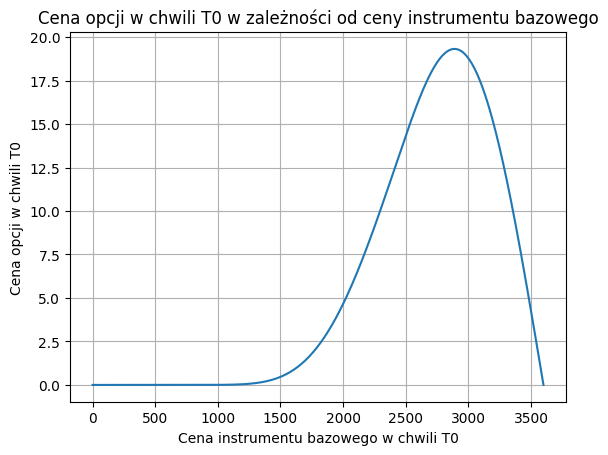

In [7]:
X = np.arange(efd.N + 1) * efd.delta_s
plt.plot(X, option_prices)
plt.xlabel("Cena instrumentu bazowego w chwili T0")
plt.ylabel("Cena opcji w chwili T0")
plt.title("Cena opcji w chwili T0 w zależności od ceny instrumentu bazowego")
plt.grid()
plt.show()

## Heatmapa wartości opcji (europejskie CALL)

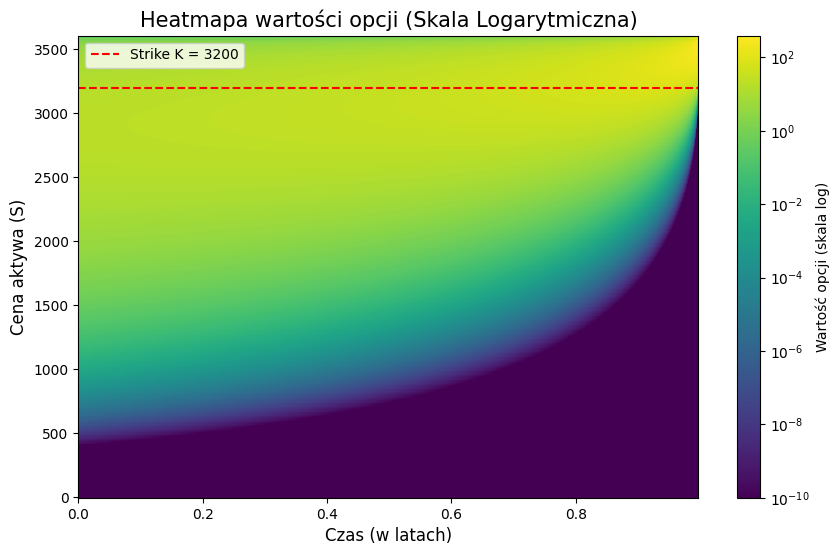

In [8]:
grid = efd.grid
N = efd.N
M = efd.M
dt = efd.delta_t
ds = efd.delta_s
strike_price = efd.strike_price

time_axis = np.arange(M + 1) * dt
price_axis = np.arange(N + 1) * ds
grid_for_plot = grid[:, ::-1]

fig, ax = plt.subplots(figsize=(10, 6))

clipped_grid = np.maximum(grid_for_plot, 1e-10) 
norm = colors.LogNorm()

c = ax.pcolormesh(time_axis, price_axis, clipped_grid, shading='auto', cmap='viridis', norm=norm)
ax.set_title('Heatmapa wartości opcji (Skala Logarytmiczna)', fontsize=15)
ax.set_xlabel('Czas (w latach)', fontsize=12)
ax.set_ylabel('Cena aktywa (S)', fontsize=12)
ax.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
ax.legend(loc='upper left')
fig.colorbar(c, ax=ax, label='Wartość opcji (skala log)')

plt.show()

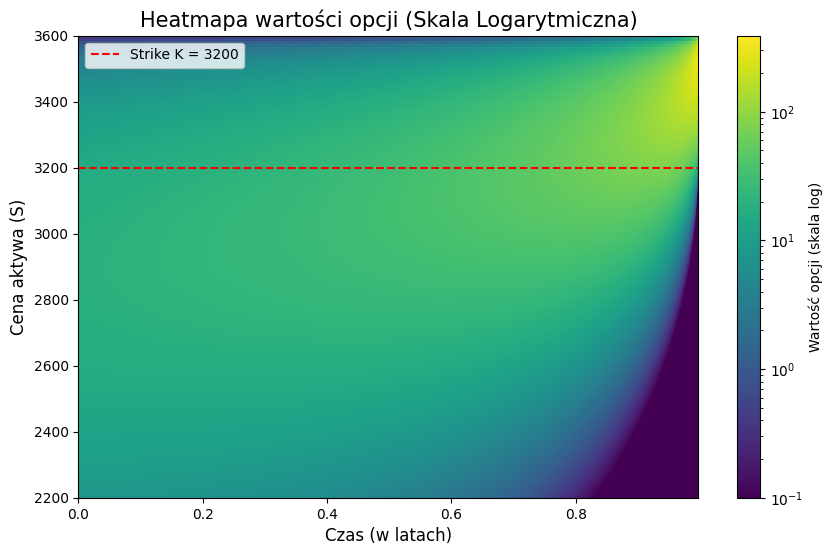

In [9]:
grid = efd.grid
N = efd.N
M = efd.M
dt = efd.delta_t
ds = efd.delta_s
strike_price = efd.strike_price

time_axis = np.arange(M + 1) * dt
price_axis = np.arange(N + 1) * ds

grid_for_plot = grid[:, ::-1]

fig, ax = plt.subplots(figsize=(10, 6))

clipped_grid = np.maximum(grid_for_plot, 1e-10) 
norm = colors.LogNorm(vmin=0.1, vmax=np.max(clipped_grid)) 

c = ax.pcolormesh(time_axis, price_axis, clipped_grid, shading='auto', cmap='viridis', norm=norm)

ax.set_title('Heatmapa wartości opcji (Skala Logarytmiczna)', fontsize=15)
ax.set_xlabel('Czas (w latach)', fontsize=12)
ax.set_ylabel('Cena aktywa (S)', fontsize=12)
ax.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
ax.legend(loc='upper left')
fig.colorbar(c, ax=ax, label='Wartość opcji (skala log)')
ax.set_ylim(2200, 3600)

plt.show()

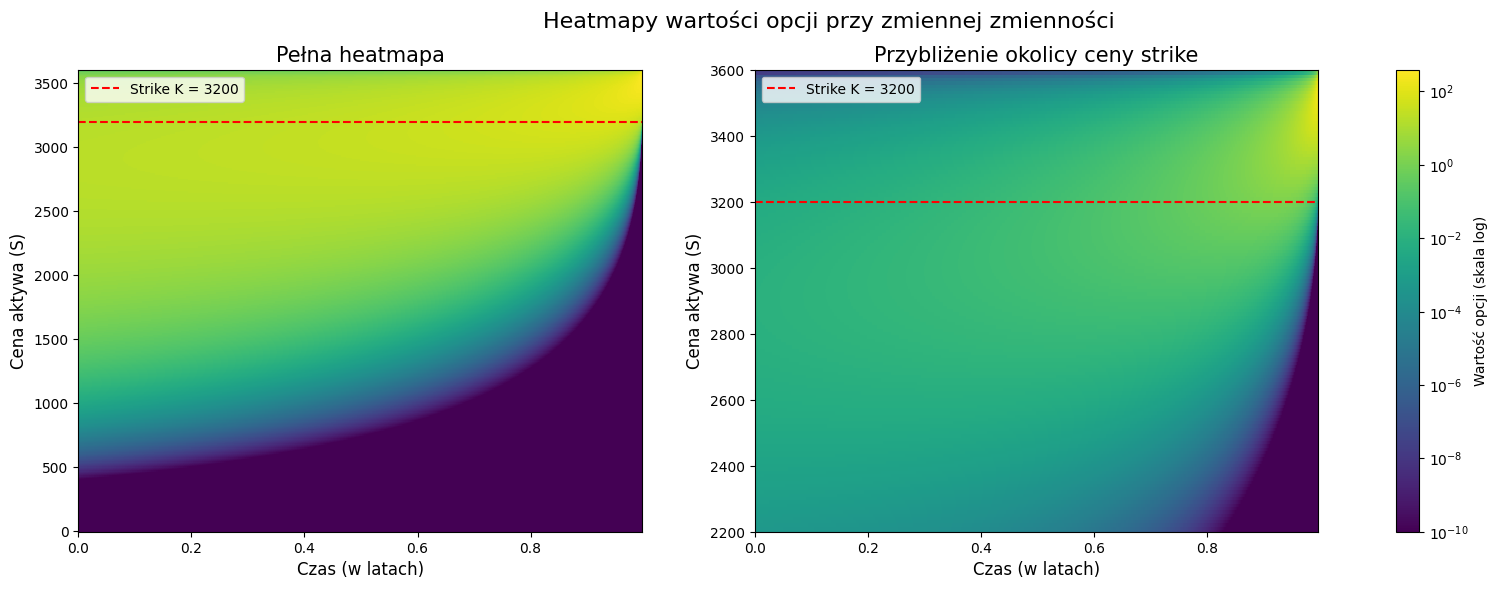

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Heatmapy wartości opcji przy zmiennej zmienności', fontsize=16)

c_1 = ax1.pcolormesh(time_axis, price_axis, clipped_grid, shading='auto', cmap='viridis', norm=colors.LogNorm())
ax1.set_title('Pełna heatmapa', fontsize=15)
ax1.set_xlabel('Czas (w latach)', fontsize=12)
ax1.set_ylabel('Cena aktywa (S)', fontsize=12)
ax1.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
ax1.legend(loc='upper left')

c_2 = ax2.pcolormesh(time_axis, price_axis, clipped_grid, shading='auto', cmap='viridis', 
                     norm=colors.LogNorm(vmin=0.1, vmax=np.max(clipped_grid)))
ax2.set_title('Przybliżenie okolicy ceny strike', fontsize=15)
ax2.set_xlabel('Czas (w latach)', fontsize=12)
ax2.set_ylabel('Cena aktywa (S)', fontsize=12)
ax2.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
ax2.legend(loc='upper left')
fig.colorbar(c_1, ax=[ax1, ax2], label='Wartość opcji (skala log)')
ax2.set_ylim(2200, 3600)

plt.show()

### Analiza wpływu zmienności

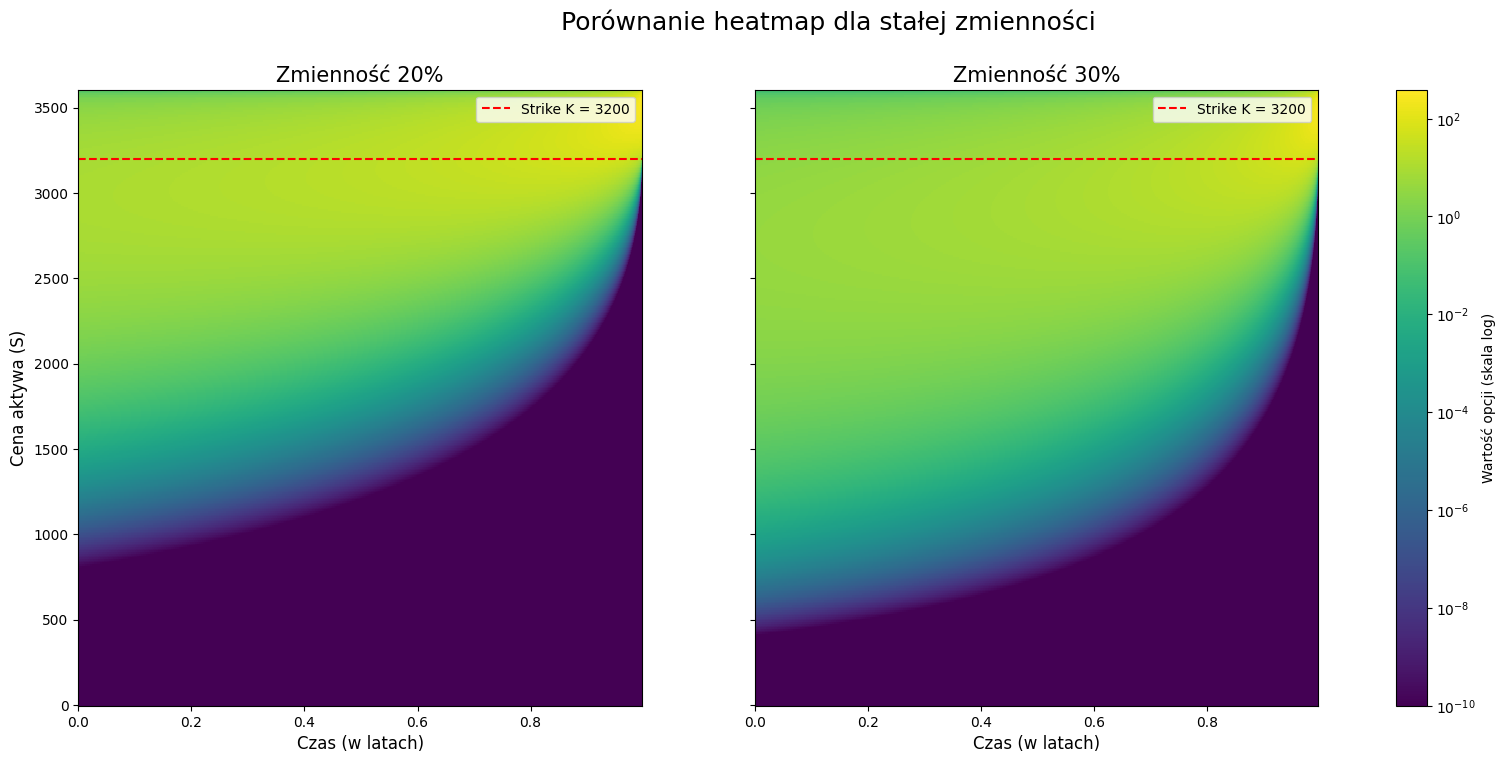

In [11]:
efd_min = copy.deepcopy(efd)
efd_max = copy.deepcopy(efd)

efd_min.calculate_grid_const_vol(efd.sigma_min)
grid_const_vol_min = np.maximum(efd_min.grid[:, ::-1], 1e-10)
efd_max.calculate_grid_const_vol(efd.sigma_max)
grid_const_vol_max = np.maximum(efd_max.grid[:, ::-1], 1e-10)

vmax = max(np.max(grid_const_vol_min), np.max(grid_const_vol_max))
norm = colors.LogNorm(vmin=1e-10, vmax=vmax)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
fig.suptitle('Porównanie heatmap dla stałej zmienności', fontsize=18)

c_1 = ax1.pcolormesh(time_axis, price_axis, grid_const_vol_min, shading='auto', cmap='viridis', norm=norm)
ax1.set_title('Zmienność 20%', fontsize=15)
ax1.set_xlabel('Czas (w latach)', fontsize=12)
ax1.set_ylabel('Cena aktywa (S)', fontsize=12)
ax1.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
ax1.legend()

c_2 = ax2.pcolormesh(time_axis, price_axis, grid_const_vol_max, shading='auto', cmap='viridis', norm=norm)
ax2.set_title('Zmienność 30%', fontsize=15)
ax2.set_xlabel('Czas (w latach)', fontsize=12)
ax2.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
ax2.legend()

fig.colorbar(c_1, ax=[ax1, ax2], label='Wartość opcji (skala log)')

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Heatmapy wartości opcji (amerykańskie CALL)

In [12]:
american_call = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.CALL,
    option_exercise_type=OptionExerciseType.AMERICAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=3600,
    
    delta_t=1/(365 * 100),
    delta_s=10,

    dividend_yield=300,
    dividend_date=datetime(2026, 6, 1),

    verbose=True
)

american_call.calculate_grid()
option_prices = american_call.get_option_prices_T0()

Initialized grid with shape: (361, 36401)


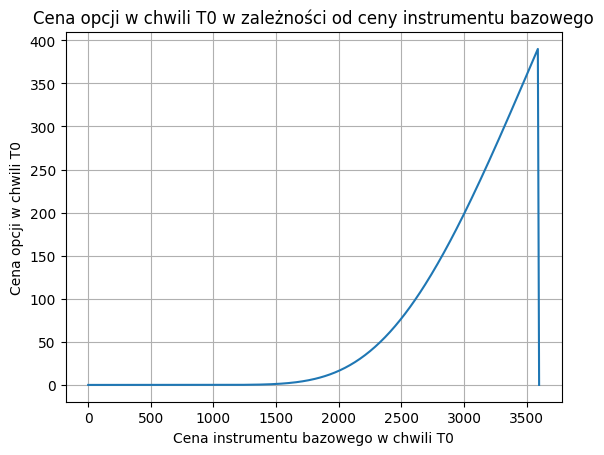

In [13]:
X = np.arange(american_call.N + 1) * american_call.delta_s
plt.plot(X, option_prices)
plt.xlabel("Cena instrumentu bazowego w chwili T0")
plt.ylabel("Cena opcji w chwili T0")
plt.title("Cena opcji w chwili T0 w zależności od ceny instrumentu bazowego")
plt.grid()
plt.show()

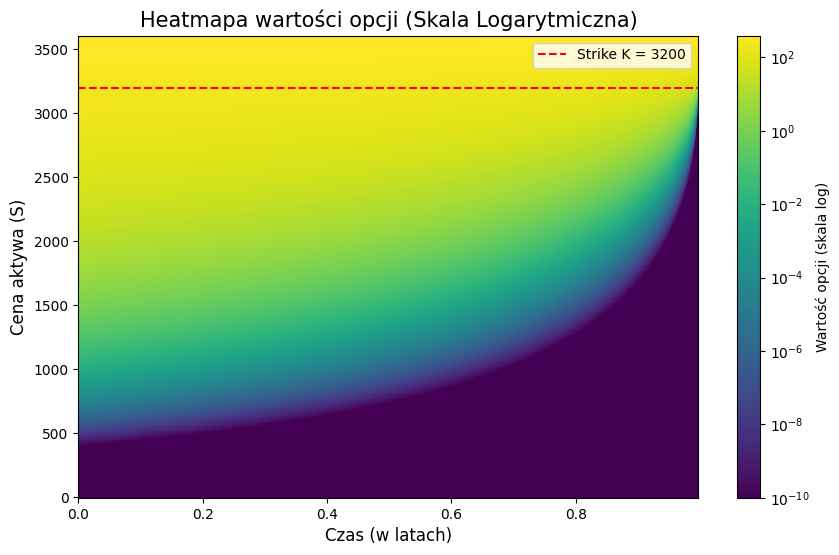

In [14]:
grid = american_call.grid
N = american_call.N
M = american_call.M
dt = american_call.delta_t
ds = american_call.delta_s
strike_price = american_call.strike_price

time_axis = np.arange(M + 1) * dt
price_axis = np.arange(N + 1) * ds
grid_for_plot = grid[:, ::-1]

fig, ax = plt.subplots(figsize=(10, 6))

clipped_grid = np.maximum(grid_for_plot, 1e-10) 
norm = colors.LogNorm()

c = ax.pcolormesh(time_axis, price_axis, clipped_grid, shading='auto', cmap='viridis', norm=norm)
ax.set_title('Heatmapa wartości opcji (Skala Logarytmiczna)', fontsize=15)
ax.set_xlabel('Czas (w latach)', fontsize=12)
ax.set_ylabel('Cena aktywa (S)', fontsize=12)
ax.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
ax.legend()
fig.colorbar(c, ax=ax, label='Wartość opcji (skala log)')

plt.show()

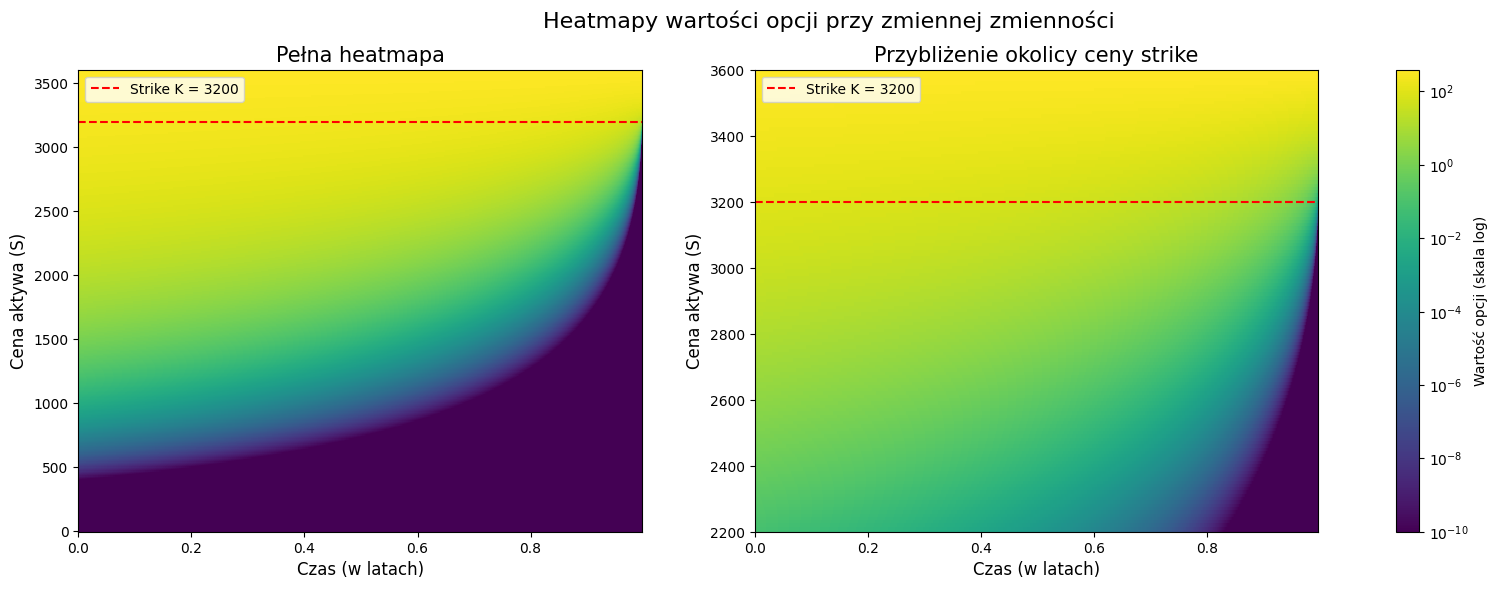

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Heatmapy wartości opcji przy zmiennej zmienności', fontsize=16)

c_1 = ax1.pcolormesh(time_axis, price_axis, clipped_grid, shading='auto', cmap='viridis', norm=colors.LogNorm())
ax1.set_title('Pełna heatmapa', fontsize=15)
ax1.set_xlabel('Czas (w latach)', fontsize=12)
ax1.set_ylabel('Cena aktywa (S)', fontsize=12)
ax1.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
ax1.legend(loc='upper left')

c_2 = ax2.pcolormesh(time_axis, price_axis, clipped_grid, shading='auto', cmap='viridis', 
                     norm=colors.LogNorm(vmin=0.1, vmax=np.max(clipped_grid)))
ax2.set_title('Przybliżenie okolicy ceny strike', fontsize=15)
ax2.set_xlabel('Czas (w latach)', fontsize=12)
ax2.set_ylabel('Cena aktywa (S)', fontsize=12)
ax2.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
ax2.legend(loc='upper left')
fig.colorbar(c_1, ax=[ax1, ax2], label='Wartość opcji (skala log)')
ax2.set_ylim(2200, 3600)

plt.show()

### Exercise opcji amerykańskich


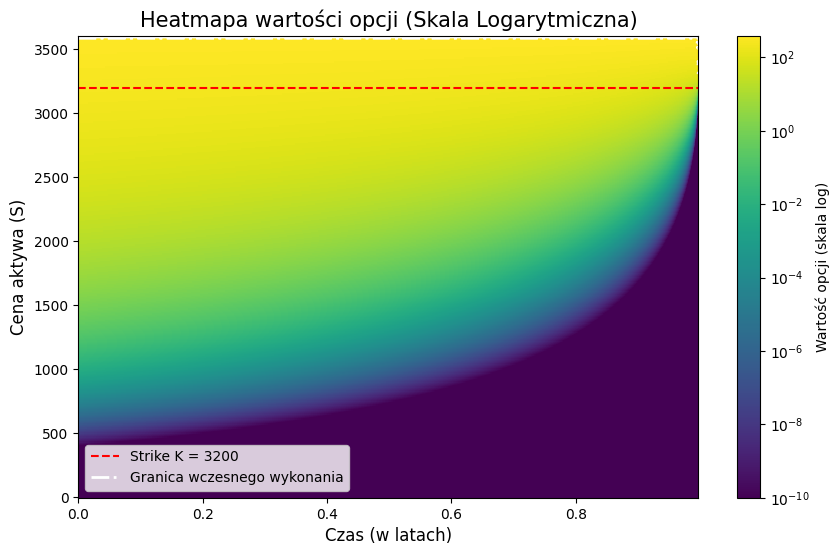

In [16]:
american_call.calculate_grid()

grid = american_call.grid
exercise = american_call.american_exercise
N = american_call.N
M = american_call.M
dt = american_call.delta_t
ds = american_call.delta_s
strike_price = american_call.strike_price

time_axis = np.arange(M + 1) * dt
price_axis = np.arange(N + 1) * ds
grid_for_plot = grid[:, ::-1]
exercise_for_plot = exercise[:, ::-1]

fig, ax = plt.subplots(figsize=(10, 6))

clipped_grid = np.maximum(grid_for_plot, 1e-10) 
norm = colors.LogNorm()

c = ax.pcolormesh(time_axis, price_axis, clipped_grid, shading='auto', cmap='viridis', norm=norm)
ax.set_title('Heatmapa wartości opcji (Skala Logarytmiczna)', fontsize=15)
ax.set_xlabel('Czas (w latach)', fontsize=12)
ax.set_ylabel('Cena aktywa (S)', fontsize=12)
ax.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
# We add contour to show the early exercise boundary for American option
CS = ax.contour(
    time_axis, 
    price_axis, 
    exercise_for_plot, 
    levels=[0.5], # We want to show the boundary where exercise changes from False to True
    colors='white', 
    linestyles='dashdot', 
    linewidths=2
)
ax.plot([], [], color='white', linestyle='dashdot', linewidth=2, label='Granica wczesnego wykonania')

ax.legend()
fig.colorbar(c, ax=ax, label='Wartość opcji (skala log)')

plt.show()

In [17]:
american_put = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.PUT,
    option_exercise_type=OptionExerciseType.AMERICAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=2800,
    
    delta_t=1/(365 * 100),
    delta_s=10,

    dividend_yield=300,
    dividend_date=datetime(2026, 6, 1),

    verbose=True
)

american_put.calculate_grid()
option_prices = american_put.get_option_prices_T0()

Initialized grid with shape: (281, 36401)


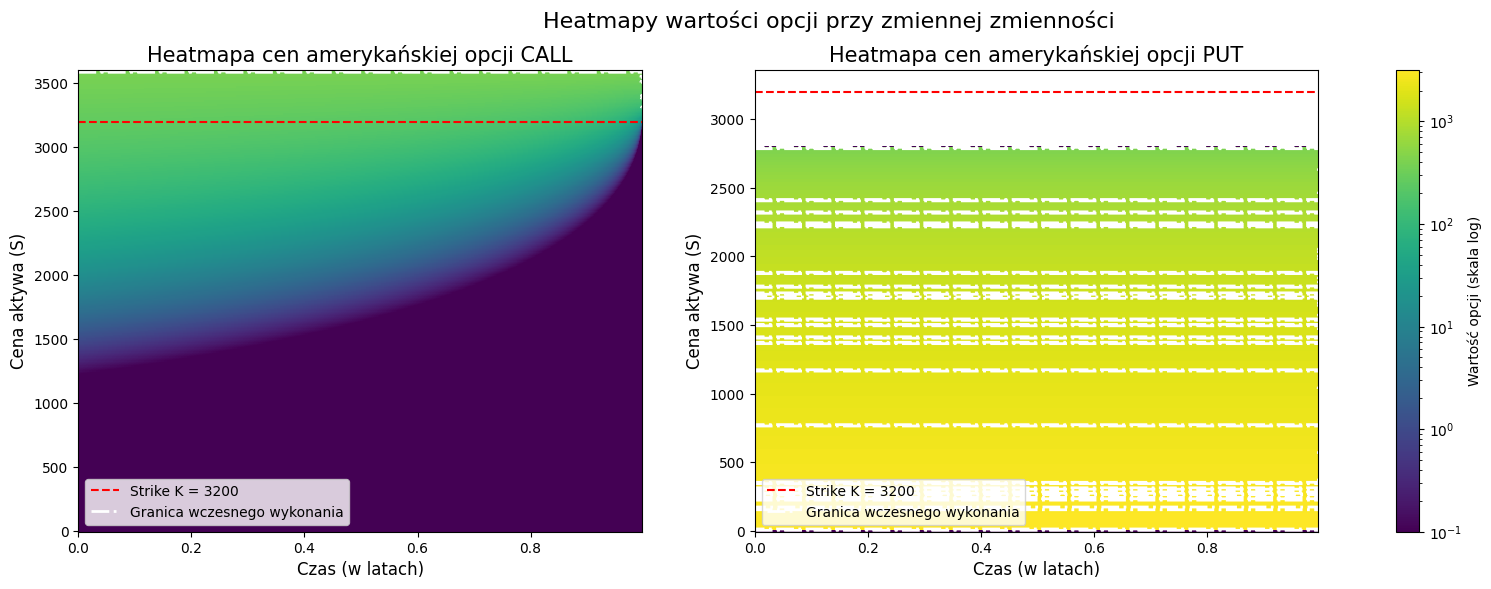

In [18]:
grid_call = american_call.grid
grid_put = american_put.grid

N_call = american_call.N
M_call = american_call.M
N_put = american_put.N
M_put = american_put.M
dt_call = american_call.delta_t
dt_put = american_put.delta_t
ds_call = american_call.delta_s
ds_put = american_put.delta_s
exercise_call = american_call.american_exercise
exercise_put = american_put.american_exercise

time_axis_call = np.arange(M_call + 1) * dt_call
time_axis_put = np.arange(M_put + 1) * dt_put
price_axis_call = np.arange(N_call + 1) * ds_call
price_axis_put = np.arange(N_put + 1) * ds_put
exercise_for_plot_call = exercise_call[:, ::-1]
exercise_for_plot_put = exercise_put[:, ::-1]

clipped_grid_call = np.maximum(grid_call[:, ::-1], 1e-10)
clipped_grid_put = np.maximum(grid_put[:, ::-1], 1e-10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Heatmapy wartości opcji przy zmiennej zmienności', fontsize=16)

c_1 = ax1.pcolormesh(time_axis_call, price_axis_call, clipped_grid_call, shading='auto', cmap='viridis', 
                     norm=colors.LogNorm(vmin=0.1, vmax=np.max(clipped_grid_put)))
ax1.set_title('Heatmapa cen amerykańskiej opcji CALL', fontsize=15)
ax1.set_xlabel('Czas (w latach)', fontsize=12)
ax1.set_ylabel('Cena aktywa (S)', fontsize=12)
ax1.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
CS = ax1.contour(
    time_axis_call, 
    price_axis_call, 
    exercise_for_plot_call, 
    levels=[0.5], # We want to show the boundary where exercise changes from False to True
    colors='white', 
    linestyles='dashdot', 
    linewidths=2
)
ax1.plot([], [], color='white', linestyle='dashdot', linewidth=2, label='Granica wczesnego wykonania')
ax1.legend(loc='lower left')

c_2 = ax2.pcolormesh(time_axis_put, price_axis_put, clipped_grid_put, shading='auto', cmap='viridis', 
                     norm=colors.LogNorm(vmin=0.1, vmax=np.max(clipped_grid_put)))
ax2.set_title('Heatmapa cen amerykańskiej opcji PUT', fontsize=15)
ax2.set_xlabel('Czas (w latach)', fontsize=12)
ax2.set_ylabel('Cena aktywa (S)', fontsize=12)
ax2.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
CS = ax2.contour(
    time_axis_put, 
    price_axis_put, 
    exercise_for_plot_put, 
    levels=[0.5], # We want to show the boundary where exercise changes from False to True
    colors='white', 
    linestyles='dashdot', 
    linewidths=2
)
ax2.plot([], [], color='white', linestyle='dashdot', linewidth=2, label='Granica wczesnego wykonania')
ax2.legend(loc='lower left')
fig.colorbar(c_1, ax=[ax1, ax2], label='Wartość opcji (skala log)')
# ax2.set_ylim(2800, 3600)

plt.show()

## Porównanie EUR vs. AMERICAN (CALL)


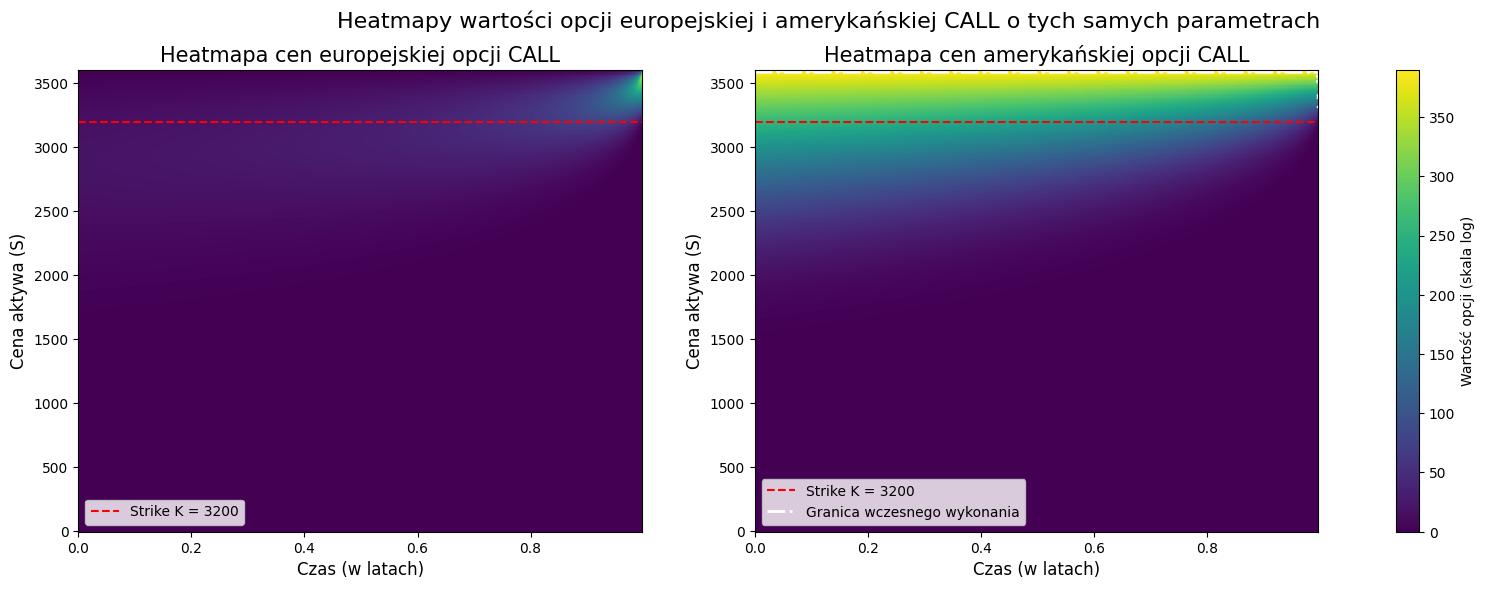

In [19]:
grid_american = american_call.grid
grid_eur = efd.grid

N = american_call.N
M = american_call.M
dt = american_call.delta_t
ds = american_call.delta_s
exercise_american = american_call.american_exercise

time_axis = np.arange(M + 1) * dt
price_axis = np.arange(N + 1) * ds
exercise_for_plot = exercise_american[:, ::-1]

clipped_grid_eur = np.maximum(grid_eur[:, ::-1], 1e-10)
clipped_grid_american = np.maximum(grid_american[:, ::-1], 1e-10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Heatmapy wartości opcji europejskiej i amerykańskiej CALL o tych samych parametrach', fontsize=16)

c_1 = ax1.pcolormesh(time_axis, price_axis, clipped_grid_eur, shading='auto', cmap='viridis')
ax1.set_title('Heatmapa cen europejskiej opcji CALL', fontsize=15)
ax1.set_xlabel('Czas (w latach)', fontsize=12)
ax1.set_ylabel('Cena aktywa (S)', fontsize=12)
ax1.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')

ax1.legend(loc='lower left')

c_2 = ax2.pcolormesh(time_axis, price_axis, clipped_grid_american, shading='auto', cmap='viridis')
ax2.set_title('Heatmapa cen amerykańskiej opcji CALL', fontsize=15)
ax2.set_xlabel('Czas (w latach)', fontsize=12)
ax2.set_ylabel('Cena aktywa (S)', fontsize=12)
ax2.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
CS = ax2.contour(
    time_axis, 
    price_axis, 
    exercise_for_plot, 
    levels=[0.5], # We want to show the boundary where exercise changes from False to True
    colors='white', 
    linestyles='dashdot', 
    linewidths=2
)
ax2.plot([], [], color='white', linestyle='dashdot', linewidth=2, label='Granica wczesnego wykonania')
ax2.legend(loc='lower left')
fig.colorbar(c_1, ax=[ax1, ax2], label='Wartość opcji (skala log)')
# ax2.set_ylim(2800, 3600)

plt.show()

## Wykresy greków

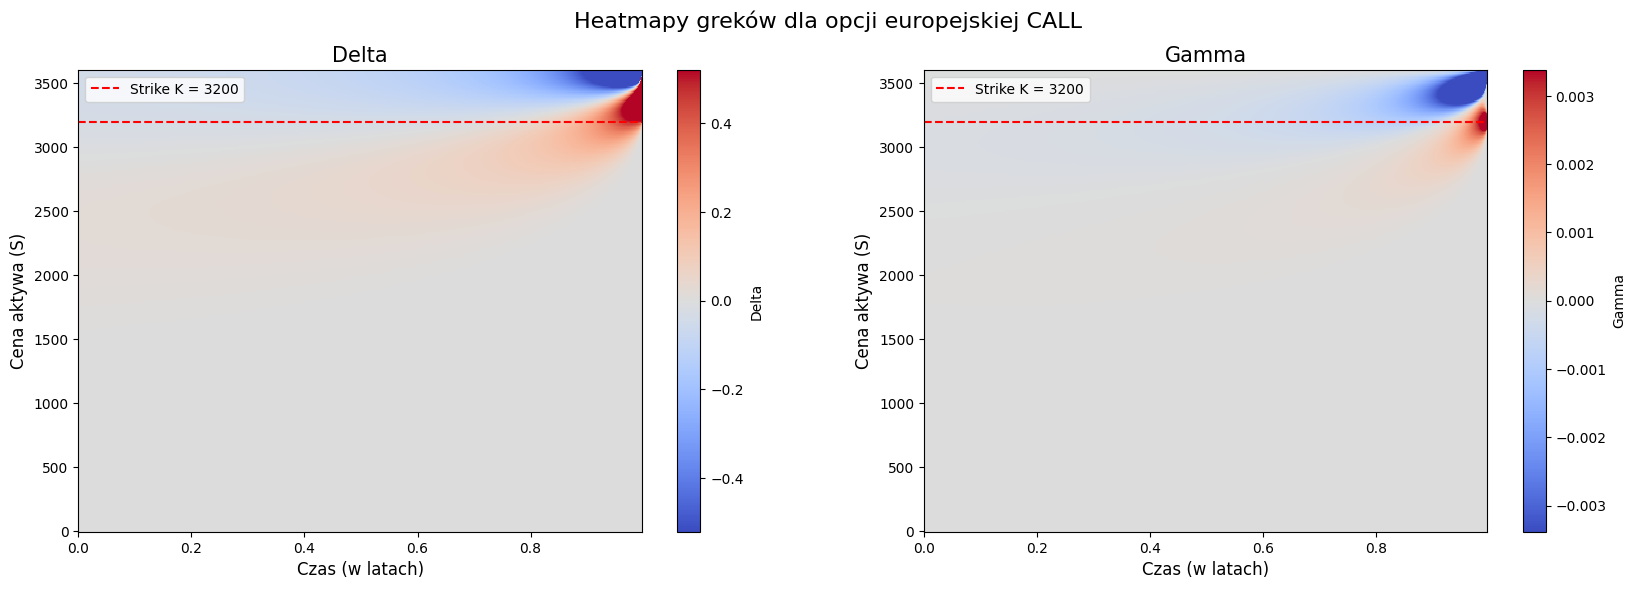

In [20]:
delta_grid = efd.delta_grid
gamma_grid = efd.gamma_grid

time_axis = np.arange(M + 1) * dt
price_axis = np.arange(N + 1) * ds
delta_grid_for_plot = delta_grid[:, ::-1]
gamma_grid_for_plot = gamma_grid[:, ::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Heatmapy greków dla opcji europejskiej CALL', fontsize=16)

delta_abs_max = np.percentile(np.abs(delta_grid_for_plot), 99.5)
div_norm_delta = colors.TwoSlopeNorm(vcenter=0., vmin=-delta_abs_max, vmax=delta_abs_max)

c_1 = ax1.pcolormesh(time_axis, price_axis, delta_grid_for_plot, shading='auto', cmap='coolwarm', 
                     norm=div_norm_delta)
ax1.set_title('Delta', fontsize=15)
ax1.set_xlabel('Czas (w latach)', fontsize=12)
ax1.set_ylabel('Cena aktywa (S)', fontsize=12)
ax1.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
ax1.legend(loc='upper left')

gamma_abs_max = np.percentile(np.abs(gamma_grid_for_plot), 99.5)
div_norm_gamma = colors.TwoSlopeNorm(vcenter=0., vmin=-gamma_abs_max, vmax=gamma_abs_max)

c_2 = ax2.pcolormesh(time_axis, price_axis, gamma_grid_for_plot, shading='auto', cmap='coolwarm', 
                      norm=div_norm_gamma)
ax2.set_title('Gamma', fontsize=15)
ax2.set_xlabel('Czas (w latach)', fontsize=12)
ax2.set_ylabel('Cena aktywa (S)', fontsize=12)
ax2.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
ax2.legend(loc='upper left')
fig.colorbar(c_1, ax=ax1, label='Delta')
fig.colorbar(c_2, ax=ax2, label='Gamma')

plt.show()

### Wykres sgn(gamma)

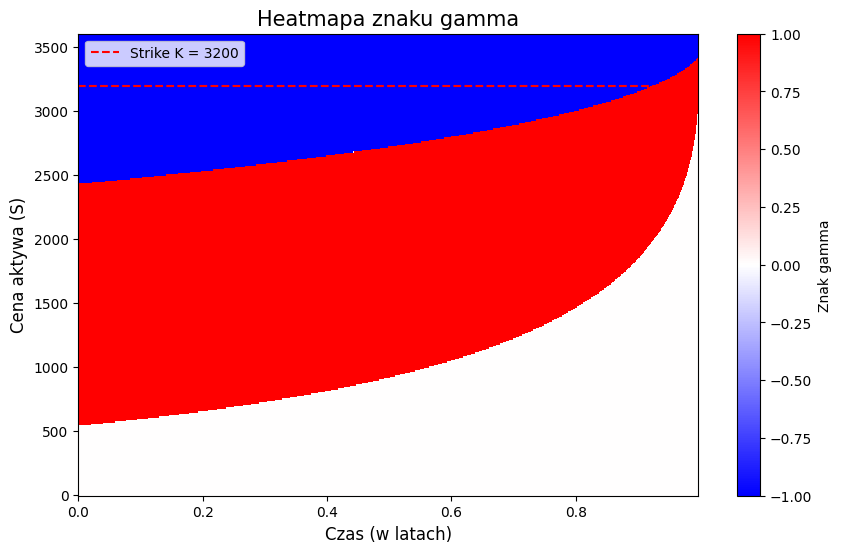

In [21]:
eps = 1e-10
sgn_grid_for_plot = np.zeros_like(gamma_grid_for_plot)

sgn_grid_for_plot[gamma_grid_for_plot > eps] = 1
sgn_grid_for_plot[gamma_grid_for_plot < -eps] = -1
plt.figure(figsize=(10, 6))

c = plt.pcolormesh(time_axis, price_axis, sgn_grid_for_plot, shading='auto', cmap='bwr', vmin=-1, vmax=1)
plt.title('Heatmapa znaku gamma', fontsize=15)
plt.xlabel('Czas (w latach)', fontsize=12)
plt.ylabel('Cena aktywa (S)', fontsize=12)
plt.axhline(y=strike_price, color='red', linestyle='--', label=f'Strike K = {strike_price}')
plt.legend(loc='upper left')
plt.colorbar(c, label='Znak gamma')
plt.show()